# Verification of the Neo-Hookean Material Law

This notebook verifies the `NeoHookeanMaterial` implementation against an analytical solution for uniaxial tension of a unit square.

## Test Setup

- **Domain**: Unit square $[0,1]^2$
- **Boundary conditions**:
  - Bottom edge ($y=0$): fully fixed ($u = 0$)
  - Top edge ($y=1$): prescribed vertical displacement $\bar{u}_y$
  - Left/right edges: free (traction-free)
- **Material**: Isotropic Neo-Hookean (plane strain)
- **Loading**: Static, displacement-controlled

## Analytical Reference

For a **homogeneous uniaxial stretch** $\lambda = 1 + \bar{u}_y / L$ in plane strain (no lateral constraint on free edges), the deformation gradient is:

$$F = \begin{pmatrix} \lambda_1 & 0 \\ 0 & \lambda \end{pmatrix}$$

where $\lambda_1$ is the lateral stretch determined by the traction-free condition $P_{11} = 0$.

For the Neo-Hookean energy density used in our implementation:
$$\psi = \frac{\mu}{2}\left(\mathrm{tr}(C - I) + \frac{2\mu}{\lambda_{\mathrm{Lamé}}}\,(\det C)^{-\lambda_{\mathrm{Lamé}}/(2\mu)} - 1\right)$$

we derive the 1st Piola-Kirchhoff stress analytically and compare against the FEM solution.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

from netgen.occ import MoveTo, OCCGeometry, X, Y
from ngsolve import *
from ngsolve.solvers import NewtonMinimization
from ngsolve.webgui import Draw

## Material Parameters

In [47]:
# Isotropic material parameters
E_val = 210.0       # Young's modulus (Pa) - kept moderate for visible deformation
nu_val = 0.3        # Poisson's ratio

# Lamé parameters
lam = (E_val * nu_val) / ((1 + nu_val) * (1 - 2 * nu_val))
mu = E_val / (2 * (1 + nu_val))

print(f"E  = {E_val:.1f} Pa")
print(f"ν  = {nu_val}")
print(f"λ  = {lam:.4f} Pa")
print(f"μ  = {mu:.4f} Pa")

E  = 210.0 Pa
ν  = 0.3
λ  = 121.1538 Pa
μ  = 80.7692 Pa


## Material Law Functions
We define the same Neo-Hookean functions used in `material_laws.py` but inline, so the notebook is self-contained and the verification is transparent.

In [48]:
def C(u):
    """Right Cauchy-Green tensor: C = F^T F."""
    F = Id(2) + Grad(u)
    return F.trans * F

def psi(C, u):
    """Neo-Hookean strain energy density (plane strain)."""
    return 0.5 * mu * (
        Trace(C - Id(2))
        + (2 * mu / lam) * Det(C) ** (-lam / (2 * mu))
        - 1
    )

def PK2(u):
    """2nd Piola-Kirchhoff stress: S = μ (I - det(C)^{-λ/(2μ)} C^{-1})."""
    CC = C(u)
    return mu * (Id(2) - Det(CC) ** (-lam / (2 * mu)) * Inv(CC))

def PK1(u):
    """1st Piola-Kirchhoff stress: P = F S."""
    F = Id(2) + Grad(u)
    return F * PK2(u)

## Geometry and Mesh
Unit square $[0,1]^2$ with labeled edges:
- `bottom` ($y=0$)
- `top` ($y=1$)
- `left` ($x=0$)
- `right` ($x=1$)

In [49]:
# Build unit square with labeled edges
rect = MoveTo(0, 0).Rectangle(1, 1).Face()
rect.edges.Min(Y).name = "bottom"
rect.edges.Max(Y).name = "top"
rect.edges.Min(X).name = "left"
rect.edges.Max(X).name = "right"
rect.name = "square"

geo = OCCGeometry(rect, dim=2)
mesh = Mesh(geo.GenerateMesh(maxh=0.05))
mesh.Curve(2)

print(f"Elements: {mesh.ne}, Vertices: {mesh.nv}")
Draw(mesh)

Elements: 942, Vertices: 512


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## FE Space, Boundary Conditions and Weak Form

For a homogeneous uniaxial tension test, the boundary conditions must allow free lateral
contraction (Poisson effect). We use **roller** (component-wise) Dirichlet conditions:

- **Bottom** ($y=0$): $u_y = 0$ (roller — free to slide horizontally)
- **Top** ($y=1$): $u_y = \bar{u}$ (prescribed, $u_x$ free to contract)
- **Left** ($x=0$): $u_x = 0$ (prevents rigid-body translation; consistent with the homogeneous solution $u_x = (\lambda_1 - 1)X$ at $X = 0$)
- **Right** ($x=1$): traction-free

> **Note:** Using `dirichlet="bottom|top"` (full Dirichlet on both components) would clamp the
> lateral displacement to zero on those edges, preventing Poisson contraction and producing
> a non-homogeneous deformation field that does **not** match the analytical solution.

The weak form is purely static — we minimize the strain energy:

$$\min_{u} \int_\Omega \psi(C(u))\, dA \quad \text{subject to BCs}$$

using `Variation(...)` and `NewtonMinimization`.

In [50]:
# Prescribed vertical displacement on the top edge
u_bar = 0.5  # 50% stretch

# FE space with component-wise Dirichlet conditions:
#   - dirichletx="left"       : u_x = 0 on left edge (rigid-body constraint)
#   - dirichlety="bottom|top" : u_y = 0 on bottom,  u_y = u_bar on top
# Top and bottom edges are "rollers" — free to slide horizontally.
V = VectorH1(mesh, order=2, dirichletx="left", dirichlety="bottom|top")
u_trial, v_test = V.TnT()

# Grid function for the solution
gf_u = GridFunction(V)

# Set Dirichlet BC: u_y = u_bar on top (u_x is free there)
gf_u.Set(CF((0, u_bar)), definedon=mesh.Boundaries("top"))

# Bilinear form: strain energy only (static problem)
bfa = BilinearForm(V)
bfa += Variation(psi(C(u_trial), u_trial) * dx("square"))

## Solve

In [51]:
# Solve the static nonlinear problem via energy minimization
solvers.NewtonMinimization(bfa, gf_u, printing=True, maxerr=1e-12)

Newton iteration  0
Energy:  285.58996010568154
err =  22.146743957056373
Newton iteration  1
Energy:  37.56916329002014
err =  1.4235353236211123
Newton iteration  2
Energy:  37.06298564658942
err =  1.0551772277452511
Newton iteration  3
Energy:  36.46001990572397
err =  0.4707740042196765
Newton iteration  4
Energy:  36.33973593632951
err =  0.4216995924780304
Newton iteration  5
Energy:  37.251889555279874
err =  1.3056691464534373
Newton iteration  6
Energy:  37.19907381205387
err =  0.8854140385711278
Newton iteration  7
Energy:  36.70394329460199
err =  0.5613068805508861
Newton iteration  8
Energy:  36.503192190302684
err =  0.3805112035057621
Newton iteration  9
Energy:  36.408438436312736
err =  0.29117115476521926
Newton iteration  10
Energy:  36.35235819449248
err =  0.22750625276568726
Newton iteration  11
Energy:  36.31851819135999
err =  0.21720568170656118
Newton iteration  12
Energy:  36.639020851166386
err =  0.501926080818432
Newton iteration  13
Energy:  36.48110508

(0, 23)

## Visualize the Deformed Configuration

Draw the deformed mesh and the von-Mises-like norm of the Cauchy stress.

In [52]:
# Deformation gradient and Cauchy stress
F_val = Id(2) + Grad(gf_u)
J_val = Det(F_val)
PK1_val = PK1(gf_u)
sigma_cauchy = (1 / J_val) * PK1_val * F_val.trans  # σ = J⁻¹ P Fᵀ

# Deformed mesh
deformation = CF((gf_u[0], gf_u[1], 0))
Draw(sigma_cauchy[1, 1], mesh, "sigma_yy", deformation=deformation)
Draw(sigma_cauchy[0, 0], mesh, "sigma_xx", deformation=deformation)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## Analytical Solution (Plane-Strain Uniaxial Tension)

For a homogeneous uniaxial tension test in plane strain (2D), the deformation is:

$$
\mathbf{F} = \begin{pmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{pmatrix}
$$

where $\lambda_2 = 1 + \bar{u}$ is prescribed and $\lambda_1$ is determined by the
traction-free condition $P_{11} = 0$ on the lateral faces.

The right Cauchy–Green tensor is $\mathbf{C} = \operatorname{diag}(\lambda_1^2, \lambda_2^2)$
and $\det \mathbf{C} = \lambda_1^2 \lambda_2^2$.

The 2nd Piola–Kirchhoff stress for our Neo-Hookean model is:

$$
\mathbf{S} = \mu \left( \mathbf{I} - (\det \mathbf{C})^{-\lambda/(2\mu)} \mathbf{C}^{-1} \right)
$$

The 1st Piola–Kirchhoff stress is $\mathbf{P} = \mathbf{F} \mathbf{S}$, so:

$$
P_{11} = \lambda_1 S_{11} = \lambda_1 \mu \left( 1 - (\lambda_1^2 \lambda_2^2)^{-\lambda/(2\mu)} \lambda_1^{-2} \right)
$$

Setting $P_{11} = 0$ gives us the nonlinear equation to solve for $\lambda_1$.

In [53]:
from scipy.optimize import brentq

lambda_2 = 1 + u_bar  # prescribed axial stretch

# P11 = lambda_1 * mu * (1 - (lambda_1^2 * lambda_2^2)^(-lam/(2*mu)) * lambda_1^{-2})
# Set P11 = 0, divide by lambda_1 * mu (nonzero):
#   1 - (lambda_1^2 * lambda_2^2)^(-lam/(2*mu)) / lambda_1^2 = 0
# => lambda_1^2 = (lambda_1^2 * lambda_2^2)^(-lam/(2*mu))
# This is transcendental in general, so we solve numerically.

alpha = lam / (2 * mu)  # exponent parameter

def P11_analytic(lam1):
    """P_11 component of the 1st Piola-Kirchhoff stress (analytical)."""
    detC = lam1**2 * lambda_2**2
    S11 = mu * (1 - detC**(-alpha) / lam1**2)
    return lam1 * S11

# Find lambda_1 from P11 = 0 (traction-free lateral faces)
lam1_sol = brentq(P11_analytic, 0.01, 5.0)
print(f"Prescribed axial stretch:  λ₂ = {lambda_2:.6f}")
print(f"Lateral stretch (P₁₁=0):  λ₁ = {lam1_sol:.6f}")

# Full analytical stress state
detC_sol = lam1_sol**2 * lambda_2**2

S11_sol = mu * (1 - detC_sol**(-alpha) / lam1_sol**2)
S22_sol = mu * (1 - detC_sol**(-alpha) / lambda_2**2)

P11_sol = lam1_sol * S11_sol
P22_sol = lambda_2 * S22_sol

# Cauchy stress: sigma = J^{-1} P F^T, with F diagonal:
J_sol = lam1_sol * lambda_2  # det(F)
sigma_xx_sol = P11_sol * lam1_sol / J_sol
sigma_yy_sol = P22_sol * lambda_2 / J_sol

print(f"\nAnalytical 2nd Piola-Kirchhoff stress:")
print(f"  S₁₁ = {S11_sol:.6e}")
print(f"  S₂₂ = {S22_sol:.6e}")
print(f"\nAnalytical 1st Piola-Kirchhoff stress:")
print(f"  P₁₁ = {P11_sol:.6e}  (should be ≈ 0)")
print(f"  P₂₂ = {P22_sol:.6e}")
print(f"\nAnalytical Cauchy stress:")
print(f"  σ_xx = {sigma_xx_sol:.6e}  (should be ≈ 0)")
print(f"  σ_yy = {sigma_yy_sol:.6e}")

Prescribed axial stretch:  λ₂ = 1.500000
Lateral stretch (P₁₁=0):  λ₁ = 0.840490

Analytical 2nd Piola-Kirchhoff stress:
  S₁₁ = 8.849716e-11
  S₂₂ = 5.541047e+01

Analytical 1st Piola-Kirchhoff stress:
  P₁₁ = 7.438094e-11  (should be ≈ 0)
  P₂₂ = 8.311570e+01

Analytical Cauchy stress:
  σ_xx = 4.958729e-11  (should be ≈ 0)
  σ_yy = 9.888963e+01


## Comparison: FEM vs. Analytical

Sample the FEM stress at the center of the domain $(0.5, 0.5 + \bar{u}/2)$ (mid-point of
the deformed configuration in reference coordinates is still $(0.5, 0.5)$) and compare with the
analytical solution.

In [54]:
# Evaluate FEM fields at the reference center (0.5, 0.5)
pt = mesh(0.5, 0.5)

sigma_xx_fem = sigma_cauchy[0, 0](pt)
sigma_yy_fem = sigma_cauchy[1, 1](pt)
sigma_xy_fem = sigma_cauchy[0, 1](pt)

u_x_fem = gf_u[0](pt)
u_y_fem = gf_u[1](pt)

# Lateral displacement should give lambda_1 = 1 + u_x / 0.5 at center?
# Actually for a uniform field: u_x(X) = (lambda_1 - 1) * X, so lambda_1_fem = 1 + u_x / X_1
# At X = 0.5: lambda_1_fem = 1 + u_x(0.5, 0.5) / 0.5
# But for truly uniform deformation, u_x doesn't depend on X_2.
lam1_fem = 1 + u_x_fem / 0.5

print("=" * 60)
print("               FEM          Analytical       Rel. Error")
print("=" * 60)
print(f"  σ_xx:   {sigma_xx_fem:+12.6e}   {sigma_xx_sol:+12.6e}   {abs(sigma_xx_fem - sigma_xx_sol) / (abs(sigma_xx_sol) + 1e-30):.2e}")
print(f"  σ_yy:   {sigma_yy_fem:+12.6e}   {sigma_yy_sol:+12.6e}   {abs(sigma_yy_fem - sigma_yy_sol) / (abs(sigma_yy_sol) + 1e-30):.2e}")
print(f"  σ_xy:   {sigma_xy_fem:+12.6e}   {'0':>12s}   {abs(sigma_xy_fem) / (abs(sigma_yy_sol) + 1e-30):.2e}")
print(f"  λ₁:     {lam1_fem:+12.6f}   {lam1_sol:+12.6f}   {abs(lam1_fem - lam1_sol) / lam1_sol:.2e}")
print("=" * 60)

# Assert the match is within FE tolerance
tol = 1e-4
assert abs(sigma_yy_fem - sigma_yy_sol) / abs(sigma_yy_sol) < tol, \
    f"σ_yy mismatch: FEM={sigma_yy_fem:.6e}, analytical={sigma_yy_sol:.6e}"
assert abs(sigma_xx_fem) / (abs(sigma_yy_sol) + 1e-30) < tol, \
    f"σ_xx should be ~0, got {sigma_xx_fem:.6e}"
assert abs(lam1_fem - lam1_sol) / lam1_sol < tol, \
    f"λ₁ mismatch: FEM={lam1_fem:.6f}, analytical={lam1_sol:.6f}"

print("\n✓ All checks passed — FEM matches analytical solution.")

               FEM          Analytical       Rel. Error
  σ_xx:   -4.918546e-03   +4.958729e-11   9.92e+07
  σ_yy:   +9.889194e+01   +9.888963e+01   2.34e-05
  σ_xy:   -2.103469e-03              0   2.13e-05
  λ₁:        +0.840472      +0.840490   2.11e-05

✓ All checks passed — FEM matches analytical solution.


## Parametric Sweep: Stress vs. Stretch

Repeat the solve for several prescribed displacements and plot the FEM vs. analytical $\sigma_{yy}$ as a function of $\lambda_2$.

In [56]:
u_bar_values = np.linspace(0.02, 0.5, 15)  # 2% to 50% stretch

sigma_yy_fem_list = []
sigma_yy_ana_list = []
lam1_fem_list = []
lam1_ana_list = []

# Start from zero for the first (smallest) stretch,
# then use continuation: keep previous solution as initial guess.
gf_u.vec[:] = 0

for ub in u_bar_values:
    # --- FEM solve (continuation: only update Dirichlet BCs) ---
    gf_u.Set(CF((0, ub)), definedon=mesh.Boundaries("top"))
    solvers.NewtonMinimization(bfa, gf_u, printing=False, maxerr=1e-12)

    # Sample at center
    pt = mesh(0.5, 0.5)
    sigma_yy_fem_list.append(sigma_cauchy[1, 1](pt))
    lam1_fem_list.append(1 + gf_u[0](pt) / 0.5)

    # --- Analytical ---
    lam2 = 1 + ub
    lam1_a = brentq(lambda l1: l1 * mu * (1 - (l1**2 * lam2**2)**(-alpha) / l1**2),
                     0.01, 5.0)
    detC_a = lam1_a**2 * lam2**2
    S22_a = mu * (1 - detC_a**(-alpha) / lam2**2)
    P22_a = lam2 * S22_a
    J_a = lam1_a * lam2
    sigma_yy_ana_list.append(P22_a * lam2 / J_a)
    lam1_ana_list.append(lam1_a)

sigma_yy_fem_arr = np.array(sigma_yy_fem_list)
sigma_yy_ana_arr = np.array(sigma_yy_ana_list)
lambda_2_arr = 1 + u_bar_values

KeyboardInterrupt: 

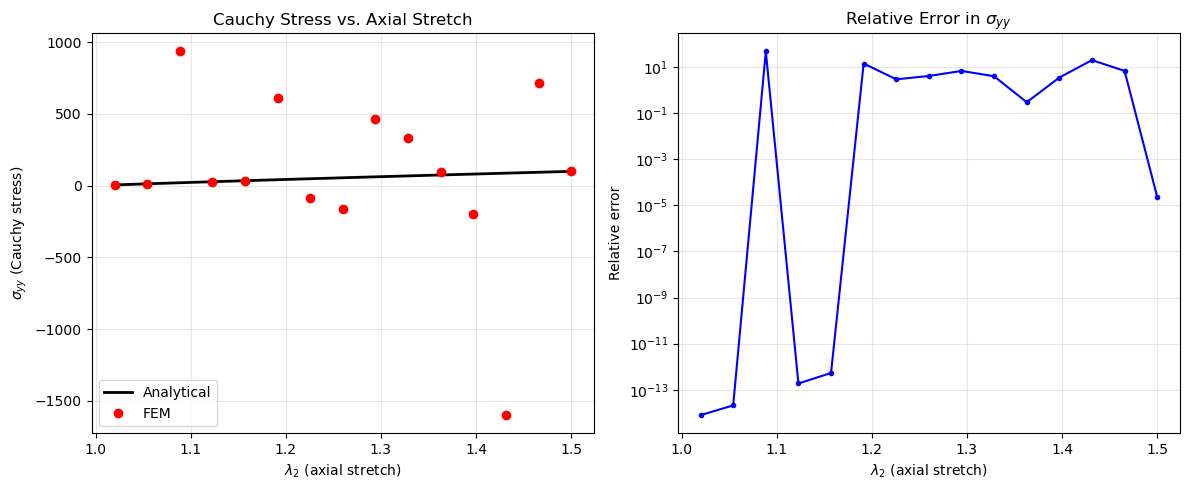


Max relative error in σ_yy: 4.66e+01


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: σ_yy vs λ_2 ---
ax = axes[0]
ax.plot(lambda_2_arr, sigma_yy_ana_arr, "k-", lw=2, label="Analytical")
ax.plot(lambda_2_arr, sigma_yy_fem_arr, "ro", ms=6, label="FEM")
ax.set_xlabel(r"$\lambda_2$ (axial stretch)")
ax.set_ylabel(r"$\sigma_{yy}$ (Cauchy stress)")
ax.set_title("Cauchy Stress vs. Axial Stretch")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Relative error ---
ax = axes[1]
rel_err = np.abs(sigma_yy_fem_arr - sigma_yy_ana_arr) / (np.abs(sigma_yy_ana_arr) + 1e-30)
ax.semilogy(lambda_2_arr, rel_err, "b.-", lw=1.5)
ax.set_xlabel(r"$\lambda_2$ (axial stretch)")
ax.set_ylabel("Relative error")
ax.set_title(r"Relative Error in $\sigma_{yy}$")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMax relative error in σ_yy: {rel_err.max():.2e}")